# EO4040 — Introducción a la Ciencia de Datos para Economía
## Sesión 3 — Análisis Exploratorio de Datos (EDA)

**Temas:** 2.1 Una variable: categóricas y continuas | 2.2 Varias variables: covarianza y combinaciones  
**Objetivos:**
- Aplicar las métricas y visualizaciones correctas para explorar una variable según su tipo
- Analizar relaciones entre pares de variables eligiendo el método adecuado según la combinación de tipos
- Interpretar correlaciones con sentido económico y sin confundirlas con causalidad

**Datasets:**
- `enigh_limpio.csv` — generado en Sesión 2 (hogares mexicanos)
- World Development Indicators (Banco Mundial) — 40+ países de América Latina y el mundo

**Herramientas:** Python · Pandas · Matplotlib · Seaborn

---

## Parte 0 — Setup

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas_datareader.wb as wb
import warnings
warnings.filterwarnings('ignore')


# Estilo visual consistente para todas las gráficas del curso
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   1.0,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
AZUL   = '#1d6fa4'
VERDE  = '#1a9641'
ROJO   = '#d7191c'
NARANJA= '#f4a11d'
MORADO = '#6a3d9a'

print('Todo listo para la sesión 3 ✅')

Todo listo para la sesión 3 ✅


---

## Parte 1 — Cargamos los datasets

### 1.1 Dataset de hogares mexicanos (de Sesión 2)

In [3]:
# Si ya tienes enigh_limpio.csv de la sesión 2, cárgalo aquí.
# Si no, lo recreamos:
try:
    df_enigh = pd.read_csv('enigh_limpio.csv')
    print(f'ENIGH cargado desde archivo: {df_enigh.shape}')
except FileNotFoundError:
    print('Recreando dataset ENIGH desde sesión 2...')
    np.random.seed(42)
    n = 150
    estados = ['Ciudad de México','Jalisco','Nuevo León','Oaxaca','Chiapas',
               'Veracruz','Guanajuato','Estado de México']
    escolaridades = ['Sin escolaridad','Primaria','Secundaria','Preparatoria',
                     'Licenciatura','Posgrado']
    df_enigh = pd.DataFrame({
        'folio_hogar':         range(1001, 1001+n),
        'estado':              np.random.choice(estados, n),
        'num_integrantes':     np.random.choice([1,2,3,4,5,6,7], n,
                                   p=[0.1,0.2,0.28,0.22,0.12,0.05,0.03]),
        'ingreso_mensual':     np.random.lognormal(9.5, 0.8, n),
        'edad_jefe_hogar':     np.random.randint(18, 85, n).astype(float),
        'escolaridad_jefe':    np.random.choice(escolaridades, n,
                                   p=[0.08,0.28,0.22,0.18,0.17,0.07]),
        'acceso_internet':     np.random.choice([1,0], n, p=[0.58,0.42]),
        'gasto_alimentacion':  np.random.lognormal(8, 0.6, n),
        'vivienda_propia':     np.random.choice(['Propia','Rentada','Prestada'], n,
                                   p=[0.6,0.28,0.12]),
    })
    print(f'Dataset recreado: {df_enigh.shape}')

df_enigh.head()

ENIGH cargado desde archivo: (150, 11)


,folio_hogar,estado,num_integrantes,ingreso_mensual,edad_jefe_hogar,escolaridad_jefe,acceso_internet,gasto_alimentacion,vivienda_propia,ingreso_mensual_imp,ingreso_faltante
0,1001,Guanajuato,3.0,19633.138999,63.0,Posgrado,1.0,6990.466343,Rentada,19633.138999,0
1,1002,Oaxaca,5.0,19411.981125,51.0,Licenciatura,1.0,2116.570192,No Especificado,19411.981125,0
2,1003,Estado de México,4.0,33177.059425,66.0,Sin Escolaridad,1.0,1809.103425,Rentada,33177.059425,0
3,1004,Chiapas,2.0,NaN,62.0,Primaria,0.0,3955.448735,Propia,13907.259492,1
4,1005,Guanajuato,3.0,5345.664748,44.0,Primaria,0.0,2140.224852,Propia,5345.664748,0


### 1.2 Datos del Banco Mundial — América Latina y el mundo

Descargamos cinco indicadores para 2022 (o el año más reciente disponible):

| Código | Indicador |
|---|---|
| `NY.GDP.PCAP.PP.CD` | PIB per cápita (PPP, USD corrientes) |
| `SI.POV.GINI` | Índice de Gini |
| `SL.UEM.TOTL.ZS` | Tasa de desempleo (% fuerza laboral) |
| `SE.XPD.TOTL.GD.ZS` | Gasto en educación (% PIB) |
| `SL.TLF.CACT.FE.ZS` | Participación femenina en la fuerza laboral (%) |

In [39]:
# Indicadores
indicadores = {
    'NY.GDP.PCAP.PP.CD': 'pib_pc_ppp',
    'SI.POV.GINI':       'gini',
    'SL.UEM.TOTL.ZS':    'desempleo',
    'SE.XPD.TOTL.GD.ZS': 'gasto_educacion',
    'SL.TLF.CACT.FE.ZS': 'participacion_fem',
}

# Países
paises_latam = [
    'ARG','BOL','BRA','CHL','COL','CRI','CUB','DOM','ECU',
    'GTM','HND','MEX','NIC','PAN','PER','PRY','SLV','URY','VEN'
]

paises_ref = [
    'USA','DEU','NOR','KOR','ZAF','NGA','IND','CHN'
]

todos_paises = paises_latam + paises_ref


# Metadata del Banco Mundial
countries = wb.get_countries()


# Descargar indicadores
df_wb = wb.download(
    indicator=indicadores,
    country=todos_paises,
    start=2018,
    end=2023
).reset_index()

df_wb.head()

,country,year,NY.GDP.PCAP.PP.CD,SI.POV.GINI,SL.UEM.TOTL.ZS,SE.XPD.TOTL.GD.ZS,SL.TLF.CACT.FE.ZS
0,Argentina,2018,24410.391906,41.7,9.220,4.87774,49.146
1,Argentina,2019,23516.826198,43.3,9.843,4.77166,50.000
2,Argentina,2020,22393.347958,42.7,11.461,5.27690,46.486
3,Argentina,2021,26300.274261,42.4,8.736,4.65393,50.260
4,Argentina,2022,29804.083236,40.7,6.805,4.79263,51.868


In [29]:
indicadores = {
    'NY.GDP.PCAP.PP.CD': 'pib_pc_ppp',
    'SI.POV.GINI':        'gini',
    'SL.UEM.TOTL.ZS':    'desempleo',
    'SE.XPD.TOTL.GD.ZS': 'gasto_educacion',
    'SL.TLF.CACT.FE.ZS': 'participacion_fem',
}

# Países de América Latina + algunos de referencia fuera de la región
paises_latam = [
    'ARG','BOL','BRA','CHL','COL','CRI','CUB','DOM','ECU',
    'GTM','HND','MEX','NIC','PAN','PER','PRY','SLV','URY','VEN',
]
paises_ref   = ['USA','DEU','NOR','KOR','ZAF','NGA','IND','CHN']
todos_paises = paises_latam + paises_ref


# Metadatos útiles
meta_region = {
    'ARG':'América Latina','BOL':'América Latina','BRA':'América Latina',
    'CHL':'América Latina','COL':'América Latina','CRI':'América Latina',
    'CUB':'América Latina','DOM':'América Latina','ECU':'América Latina',
    'GTM':'América Latina','HND':'América Latina','MEX':'América Latina',
    'NIC':'América Latina','PAN':'América Latina','PER':'América Latina',
    'PRY':'América Latina','SLV':'América Latina','URY':'América Latina',
    'VEN':'América Latina',
    'USA':'América del Norte','DEU':'Europa','NOR':'Europa',
    'KOR':'Asia','ZAF':'África','NGA':'África','IND':'Asia','CHN':'Asia',
}
meta_nombre = {
    'ARG':'Argentina','BOL':'Bolivia','BRA':'Brasil','CHL':'Chile',
    'COL':'Colombia','CRI':'Costa Rica','CUB':'Cuba','DOM':'Rep. Dominicana',
    'ECU':'Ecuador','GTM':'Guatemala','HND':'Honduras','MEX':'México',
    'NIC':'Nicaragua','PAN':'Panamá','PER':'Perú','PRY':'Paraguay',
    'SLV':'El Salvador','URY':'Uruguay','VEN':'Venezuela',
    'USA':'Estados Unidos','DEU':'Alemania','NOR':'Noruega',
    'KOR':'Corea del Sur','ZAF':'Sudáfrica','NGA':'Nigeria',
    'IND':'India','CHN':'China',
}

In [ ]:
# ── Descargamos todos los indicadores de una vez con wb.download()
# Resultado: DataFrame con columnas country, year + un código por indicador

df_wb_long = wb.download(
    indicator=list(indicadores.keys()),
    country=todos_paises,
    start=2018,
    end=2023,
    errors='ignore'
).reset_index()

# wb.download() devuelve los códigos como nombres de columna; renombramos
df_wb_long = df_wb_long.rename(columns=indicadores)
# columnas ahora: country, year, pib_pc_ppp, gini, desempleo, gasto_educacion, participacion_fem

# Para cada país tomamos el último año con al menos un dato disponible
df_wb = (
    df_wb_long
    .sort_values('year')
    .groupby('country', as_index=False)
    .last()
)

print(f'Shape: {df_wb.shape}')
print(df_wb.head())

In [ ]:
# Agregamos región y nombre en español usando los diccionarios de metadatos
# La columna 'country' contiene el nombre en inglés que devuelve pandas_datareader
# Construimos un mapa nombre_inglés → iso3 para poder cruzar con meta_region / meta_nombre
countries_meta = wb.get_countries()
# countries_meta tiene columnas: 'name', 'iso2c', 'iso3c' (o similar según versión)
# Normalizamos: buscamos la columna con el código de 3 letras
iso3_col = [c for c in countries_meta.columns if 'iso3' in c.lower() or c.lower() == 'id']
iso3_col = iso3_col[0] if iso3_col else 'iso3c'

name_to_iso3 = countries_meta.set_index('name')[iso3_col].to_dict()
df_wb['iso3']   = df_wb['country'].map(name_to_iso3)
df_wb['region'] = df_wb['iso3'].map(meta_region)
df_wb['pais']   = df_wb['iso3'].map(meta_nombre)

# Para países que no mapearon por nombre exacto, intentamos por iso3 directo
# (pandas_datareader a veces devuelve el nombre oficial largo)
missing = df_wb['iso3'].isna()
if missing.any():
    # Fallback: buscar en todos_paises cuál corresponde por posición
    iso_fallback = {v: k for k, v in meta_nombre.items()}  # nombre_español → iso3
    # También mapeamos desde el índice original del download
    for iso in todos_paises:
        row_match = countries_meta[countries_meta[iso3_col] == iso]
        if not row_match.empty:
            official_name = row_match.iloc[0]['name']
            mask = df_wb['country'] == official_name
            df_wb.loc[mask, 'iso3']   = iso
            df_wb.loc[mask, 'region'] = meta_region.get(iso)
            df_wb.loc[mask, 'pais']   = meta_nombre.get(iso)

print(f'Dataset Banco Mundial: {df_wb.shape}')
print(f'Faltantes por columna:\n{df_wb.isnull().sum()}')
df_wb.head(10)

In [ ]:
# ── Dataset más amplio: todos los países, para gráficas de distribución global
# Usamos wb.download() con country='all' y un subconjunto de indicadores

ind_globales = {
    'NY.GDP.PCAP.CD': 'gdp_per_capita',
    'SL.UEM.TOTL.ZS': 'unemployment',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.POP.TOTL':    'population',
    'FP.CPI.TOTL.ZG': 'inflation',
    'SI.POV.GINI':    'gini'
}

df_global_long = wb.download(
    indicator=list(ind_globales.keys()),
    country='all',
    start=2020,
    end=2022,
    errors='ignore'
).reset_index().rename(columns=ind_globales)

# Último año disponible por país
df_global = (
    df_global_long
    .sort_values('year')
    .groupby('country', as_index=False)
    .last()
)

# Cruzamos con metadata de wb.get_countries() para tener región
# countries_meta ya fue descargado en la celda anterior
region_map = countries_meta.set_index('name')['region'].to_dict()
df_global['region'] = df_global['country'].map(region_map)

# df_wb sigue siendo el dataset de los países seleccionados (27 países)
# df_global es el dataset amplio (todos los países del mundo)
# Las celdas posteriores usan df_wb para análisis detallado
# y pueden usar df_global['gdp_per_capita'] para la distribución global

# Reasignamos NY.GDP.PCAP.CD al nombre que usan las celdas siguientes
df_wb['NY.GDP.PCAP.CD'] = df_wb.get('pib_pc_ppp')   # alias para compatibilidad

print(f"Dataset global: {df_global['country'].nunique()} países y {len(ind_globales)} indicadores")
print(f"Dataset seleccionado (27 países): {df_wb.shape}")

---

## Parte 2 — Tema 2.1: Análisis de UNA variable

> **Regla de oro:** el tipo de variable determina qué estadístico calculas y qué gráfica usas.  
> Usar la herramienta incorrecta produce conclusiones incorrectas.

### Tabla de referencia rápida

| Tipo de variable | Estadísticos | Gráficas |
|---|---|---|
| Categórica nominal | Frecuencia, proporción, moda | Barras, pie (pocas categorías) |
| Categórica ordinal | Frecuencia acumulada + los anteriores | Barras ordenadas |
| Numérica continua | Media, mediana, desviación estándar, percentiles, asimetría, curtosis | Histograma, box plot, KDE |
| Numérica discreta | Todos los anteriores, con cuidado | Histograma con bins enteros |

---
### 2.1 Variables categóricas

In [5]:
# ── Escolaridad del jefe de hogar (categórica ORDINAL)
orden_esc = ['Sin escolaridad','Primaria','Secundaria',
             'Preparatoria','Licenciatura','Posgrado']

# Frecuencias y proporciones
freq = (df_enigh['escolaridad_jefe']
        .value_counts()
        .reindex(orden_esc, fill_value=0))

tabla_esc = pd.DataFrame({
    'n':              freq,
    'proporción (%)': (freq / freq.sum() * 100).round(1),
    'acumulada (%)':  (freq / freq.sum() * 100).cumsum().round(1),
})
print('Distribución de escolaridad del jefe de hogar')
print(tabla_esc)
print(f"\nModa: {df_enigh['escolaridad_jefe'].mode()[0]}")

Distribución de escolaridad del jefe de hogar
                   n  proporción (%)  acumulada (%)
escolaridad_jefe                                   
Sin escolaridad    0             0.0            0.0
Primaria          41            35.0           35.0
Secundaria        31            26.5           61.5
Preparatoria      12            10.3           71.8
Licenciatura      15            12.8           84.6
Posgrado          18            15.4          100.0

Moda: Primaria


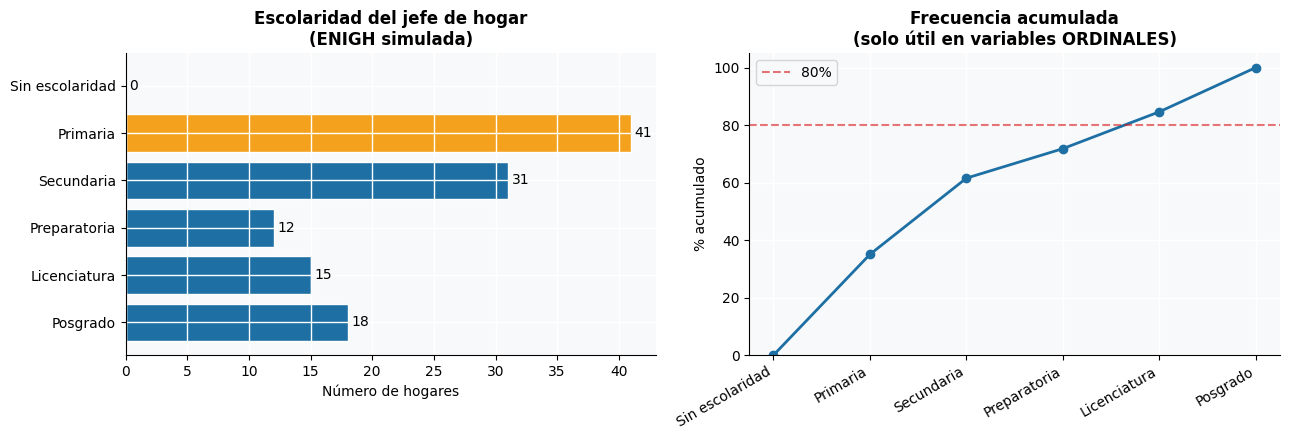


💡 La frecuencia acumulada solo tiene sentido en variables ordinales.
   Para "región" o "tipo de vivienda" (nominales) no suma ningún significado.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Gráfica 1 — barras ordenadas (ordinal → siempre respetar el orden)
colores = [AZUL if v != freq.max() else NARANJA for v in freq.values]
axes[0].barh(freq.index, freq.values, color=colores, edgecolor='white')
axes[0].set_xlabel('Número de hogares')
axes[0].set_title('Escolaridad del jefe de hogar\n(ENIGH simulada)', fontweight='bold')
for i, v in enumerate(freq.values):
    axes[0].text(v + 0.3, i, f'{v}', va='center', fontsize=10)
axes[0].invert_yaxis()

# Gráfica 2 — frecuencia acumulada (útil en ordinales)
acum = (freq / freq.sum() * 100).cumsum()
axes[1].plot(range(len(acum)), acum.values, marker='o', color=AZUL, linewidth=2)
axes[1].set_xticks(range(len(acum)))
axes[1].set_xticklabels(acum.index, rotation=30, ha='right')
axes[1].set_ylabel('% acumulado')
axes[1].set_title('Frecuencia acumulada\n(solo útil en variables ORDINALES)', fontweight='bold')
axes[1].axhline(80, color=ROJO, linestyle='--', alpha=0.6, label='80%')
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('fig_categorica_escolaridad.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 La frecuencia acumulada solo tiene sentido en variables ordinales.')
print('   Para "región" o "tipo de vivienda" (nominales) no suma ningún significado.')

Países por región en nuestro dataset:
region
Europe & Central Asia                                174
Sub-Saharan Africa                                   144
Aggregates                                           138
Latin America & Caribbean                            126
East Asia & Pacific                                  111
Middle East, North Africa, Afghanistan & Pakistan     69
South Asia                                            18
North America                                          9
Name: count, dtype: int64


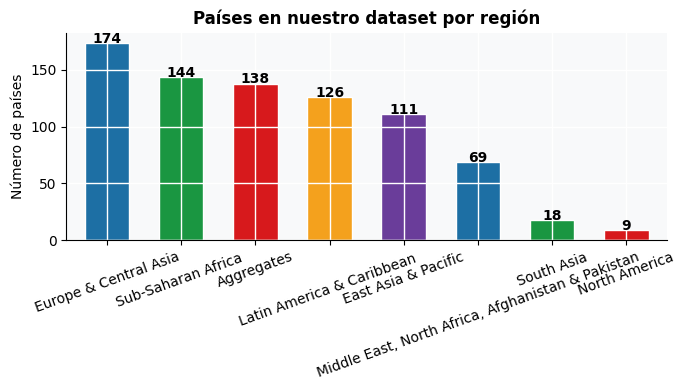


💡 Para nominales NO se ordena por orden alfabético sino por frecuencia.
   Y la frecuencia acumulada aquí NO tiene sentido.


In [13]:
# ── Región en el dataset del Banco Mundial (categórica NOMINAL)
freq_region = df_wb['region'].fillna(0).value_counts()
print('Países por región en nuestro dataset:')
print(freq_region)

fig, ax = plt.subplots(figsize=(7, 4))
freq_region.plot.bar(ax=ax, color=[AZUL, VERDE, ROJO, NARANJA, MORADO],
                     edgecolor='white', width=0.6)
ax.set_title('Países en nuestro dataset por región', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Número de países')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(freq_region.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('\n💡 Para nominales NO se ordena por orden alfabético sino por frecuencia.')
print('   Y la frecuencia acumulada aquí NO tiene sentido.')

---
### 2.2 Variables continuas

Para una variable continua necesitamos:
1. **Tendencia central** — ¿dónde está el centro de los datos?
2. **Dispersión** — ¿qué tan separados están los datos del centro?
3. **Forma** — ¿es simétrica la distribución? ¿tiene colas largas?

In [14]:
# ── Estadísticos completos para el ingreso mensual
ing = df_enigh['ingreso_mensual'].dropna()

stats = {
    'n':              int(ing.count()),
    'media':          ing.mean(),
    'mediana (p50)':  ing.median(),
    'moda (aprox.)':  'N/A en continua',
    'desv. estándar': ing.std(),
    'coef. variación':ing.std() / ing.mean(),
    'mín':            ing.min(),
    'p10':            ing.quantile(0.10),
    'p25 (Q1)':       ing.quantile(0.25),
    'p75 (Q3)':       ing.quantile(0.75),
    'p90':            ing.quantile(0.90),
    'p99':            ing.quantile(0.99),
    'máx':            ing.max(),
    'asimetría':      ing.skew(),
    'curtosis':       ing.kurtosis(),
}

for k, v in stats.items():
    if isinstance(v, float):
        print(f'  {k:<25}: {v:>12,.1f}')
    else:
        print(f'  {k:<25}: {v}')

brecha = (ing.mean() / ing.median() - 1) * 100
print(f"\n  ⚠  La media es {brecha:.1f}% mayor que la mediana.")
print("     Esto indica asimetría positiva: hay pocos hogares con ingresos muy altos")
print("     que jalan la media hacia arriba. En ingresos, la MEDIANA representa mejor al hogar típico.")

  n                        : 130
  media                    :     17,954.1
  mediana (p50)            :     13,907.3
  moda (aprox.)            : N/A en continua
  desv. estándar           :     15,040.6
  coef. variación          :          0.8
  mín                      :        905.7
  p10                      :      3,931.4
  p25 (Q1)                 :      6,676.4
  p75 (Q3)                 :     23,611.8
  p90                      :     39,144.6
  p99                      :     65,505.3
  máx                      :     74,203.3
  asimetría                :          1.5
  curtosis                 :          2.0

  ⚠  La media es 29.1% mayor que la mediana.
     Esto indica asimetría positiva: hay pocos hogares con ingresos muy altos
     que jalan la media hacia arriba. En ingresos, la MEDIANA representa mejor al hogar típico.


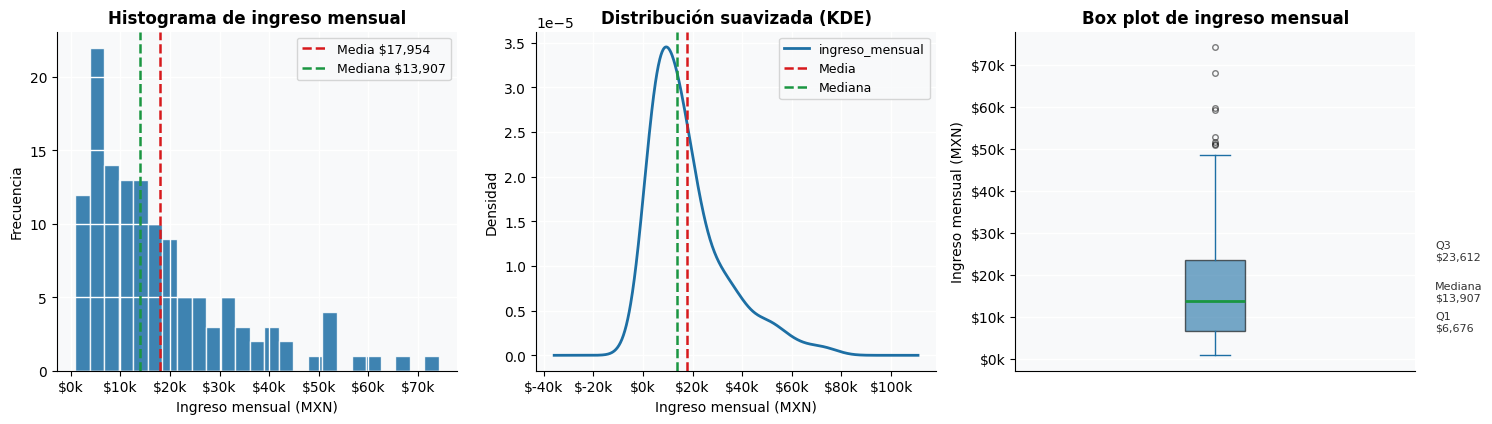

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Histograma
axes[0].hist(ing, bins=25, color=AZUL, edgecolor='white', alpha=0.85)
axes[0].axvline(ing.mean(),   color=ROJO,   linestyle='--', linewidth=1.8, label=f'Media ${ing.mean():,.0f}')
axes[0].axvline(ing.median(), color=VERDE,  linestyle='--', linewidth=1.8, label=f'Mediana ${ing.median():,.0f}')
axes[0].set_title('Histograma de ingreso mensual', fontweight='bold')
axes[0].set_xlabel('Ingreso mensual (MXN)')
axes[0].set_ylabel('Frecuencia')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(fontsize=9)

# KDE (distribución suavizada)
ing.plot.kde(ax=axes[1], color=AZUL, linewidth=2)
axes[1].axvline(ing.mean(),   color=ROJO,  linestyle='--', linewidth=1.8, label='Media')
axes[1].axvline(ing.median(), color=VERDE, linestyle='--', linewidth=1.8, label='Mediana')
axes[1].set_title('Distribución suavizada (KDE)', fontweight='bold')
axes[1].set_xlabel('Ingreso mensual (MXN)')
axes[1].set_ylabel('Densidad')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend(fontsize=9)

# Box plot
bp = axes[2].boxplot(ing, vert=True, patch_artist=True,
                     boxprops=dict(facecolor=AZUL, alpha=0.6),
                     medianprops=dict(color=VERDE, linewidth=2),
                     whiskerprops=dict(color=AZUL),
                     capprops=dict(color=AZUL),
                     flierprops=dict(marker='o', color=ROJO, alpha=0.5, markersize=4))
axes[2].set_title('Box plot de ingreso mensual', fontweight='bold')
axes[2].set_ylabel('Ingreso mensual (MXN)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[2].set_xticks([])
# Anotar cuartiles
for val, label in [(ing.quantile(.25),'Q1'), (ing.median(),'Mediana'), (ing.quantile(.75),'Q3')]:
    axes[2].annotate(f'{label}\n${val:,.0f}', xy=(1.05, val),
                     xycoords=('axes fraction','data'),
                     fontsize=8, color='#333')

plt.tight_layout()
plt.savefig('fig_continua_ingreso.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ── PIB per cápita global — asimetría dramática entre países
# Usamos df_global que tiene todos los países del mundo
pib = df_global['gdp_per_capita'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala lineal — muy sesgada
axes[0].hist(pib, bins=15, color=AZUL, edgecolor='white', alpha=0.85)
axes[0].axvline(pib.mean(),   color=ROJO,  linestyle='--', linewidth=1.8, label=f'Media ${pib.mean():,.0f}')
axes[0].axvline(pib.median(), color=VERDE, linestyle='--', linewidth=1.8, label=f'Mediana ${pib.median():,.0f}')
axes[0].set_title('PIB per cápita — escala lineal', fontweight='bold')
axes[0].set_xlabel('USD')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
axes[0].legend(fontsize=9)

# Escala logarítmica — mucho más informativa
pib_pos = pib[pib > 0]
axes[1].hist(np.log10(pib_pos), bins=15, color=MORADO, edgecolor='white', alpha=0.85)
axes[1].axvline(np.log10(pib_pos.mean()),   color=ROJO,  linestyle='--', linewidth=1.8, label='Media (log)')
axes[1].axvline(np.log10(pib_pos.median()), color=VERDE, linestyle='--', linewidth=1.8, label='Mediana (log)')
axes[1].set_title('PIB per cápita — escala log₁₀', fontweight='bold')
axes[1].set_xlabel('log₁₀(USD)')
axes[1].set_xticks([3.5, 4, 4.5, 5])
axes[1].set_xticklabels(['$3,162','$10,000','$31,623','$100,000'])
axes[1].legend(fontsize=9)

plt.suptitle('El mismo dato, dos escalas — la escala importa',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_pib_escala.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'\n  Asimetría (skewness) del PIB per cápita: {pib.skew():.2f}')
print('  Regla práctica: skewness > 1 → considerar transformación logarítmica.')

#### 🔍 Pausa de reflexión — ¿media o mediana?

| Situación | Usar |
|---|---|
| Distribución simétrica (p. ej. tallas de ropa) | Media |
| Distribución asimétrica (ingresos, precios de casas, PIB) | **Mediana** |
| Variable ordinal (nivel educativo) | **Mediana o moda** — ¡nunca media! |
| Comparar variabilidad entre grupos con distintas medias | Coeficiente de variación (σ/μ) |

**Ejemplo real:** el FMI reporta PIB per cápita promedio de $13,000 USD para América Latina.  
Pero la mediana está cerca de $9,000 USD. ¿Por qué? Brasil, Chile y Argentina jalan el promedio hacia arriba.

---

## Parte 3 — Tema 2.2: Análisis de DOS variables

Con dos variables hay **tres combinaciones posibles**, y cada una requiere herramientas distintas:

| Combinación | Estadístico | Gráfica |
|---|---|---|
| Numérica × Numérica | Covarianza · Correlación de Pearson (o Spearman) | Scatter plot · Heatmap de correlación |
| Numérica × Categórica | Media/mediana por grupo · Prueba de diferencia de medias | Box plot agrupado · Violin plot |
| Categórica × Categórica | Tabla de contingencia · Chi-cuadrado | Heatmap · Barras agrupadas |

---
### 3.1 Numérica × Numérica — Correlación

#### Conceptos clave

**Covarianza:** mide si dos variables se mueven juntas. El problema es que su magnitud depende de las unidades.

$$\text{Cov}(X,Y) = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})$$

**Correlación de Pearson:** covarianza estandarizada. Siempre entre -1 y +1. Sin unidades.

$$r = \frac{\text{Cov}(X,Y)}{\sigma_X \cdot \sigma_Y}$$

In [ ]:
# ── Curva de Okun: ¿relación entre crecimiento del PIB y desempleo?
# Ley de Okun: cuando el PIB crece, el desempleo baja (correlación negativa)

# Descargamos crecimiento del PIB con pandas_datareader.wb.download()
try:
    crec_long = wb.download(
        indicator='NY.GDP.MKTP.KD.ZG',
        country=todos_paises,
        start=2018,
        end=2023,
        errors='ignore'
    ).reset_index()
    crec_long.columns = ['country', 'year', 'crec_pib']

    # Último año disponible por país
    crec_ultimo = (
        crec_long.dropna(subset=['crec_pib'])
        .sort_values('year')
        .groupby('country')['crec_pib']
        .last()
    )
    df_wb['crec_pib'] = df_wb['country'].map(crec_ultimo)
except Exception as e:
    print(f'⚠ Descarga falló ({e}), simulando datos...')
    np.random.seed(7)
    df_wb['crec_pib'] = df_wb['desempleo'].apply(
        lambda d: -0.4 * d + 5 + np.random.normal(0, 1.5) if pd.notna(d) else np.nan)

okun = df_wb[['country', 'pais', 'region', 'crec_pib', 'desempleo']].dropna()

cov  = okun['crec_pib'].cov(okun['desempleo'])
corr = okun['crec_pib'].corr(okun['desempleo'])
print(f'Covarianza (crecim. PIB, desempleo):   {cov:8.3f}  ← depende de unidades, difícil de interpretar')
print(f'Correlación de Pearson:                 {corr:8.3f}  ← entre -1 y +1, sin unidades')
print(f'\nInterpretación: correlación de {corr:.2f} → {"negativa" if corr < 0 else "positiva"}')
print('Consistente con la Ley de Okun: cuando el PIB crece, el desempleo tiende a bajar.')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

colores_region = {
    'América Latina':    AZUL,
    'América del Norte': VERDE,
    'Europa':            MORADO,
    'Asia':              NARANJA,
    'África':            ROJO,
}

for region, grupo in okun.groupby('region'):
    ax.scatter(grupo['crec_pib'], grupo['desempleo'],
               color=colores_region.get(region, 'gray'),
               s=80, alpha=0.85, label=region, zorder=3)

# Línea de tendencia
m, b = np.polyfit(okun['crec_pib'], okun['desempleo'], 1)
x_line = np.linspace(okun['crec_pib'].min() - 0.5, okun['crec_pib'].max() + 0.5, 100)
ax.plot(x_line, m * x_line + b, color='#333', linestyle='--', linewidth=1.5,
        label=f'Tendencia (pendiente={m:.2f})', zorder=2)

# Etiquetas de países seleccionados
paises_etiquetar = ['Brasil','Chile','México','Argentina','Alemania',
                    'Estados Unidos','Colombia','Perú','Sudáfrica']
for _, row in okun.iterrows():
    if row['pais'] in paises_etiquetar:
        ax.annotate(row['pais'], (row['crec_pib'], row['desempleo']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7.5, color='#333')

ax.set_xlabel('Crecimiento del PIB (%)', fontsize=11)
ax.set_ylabel('Tasa de desempleo (%)', fontsize=11)
ax.set_title(
    f'Curva de Okun — Crecimiento del PIB vs. Desempleo\n'
    f'r = {corr:.2f}  |  Banco Mundial, año más reciente disponible',
    fontweight='bold'
)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

plt.tight_layout()
plt.savefig('fig_okun.png', dpi=130, bbox_inches='tight')
plt.show()

In [ ]:
# ── Matriz de correlación completa
# En proyectos reales, la matriz de correlación es el PRIMER paso para entender
# qué variables vale la pena explorar juntas.

numericas_wb = df_wb[['pib_pc_ppp','gini','desempleo','gasto_educacion',
                        'participacion_fem','crec_pib']].dropna()

etiquetas = {
    'pib_pc_ppp':        'PIB per cápita\n(PPP)',
    'gini':              'Índice\nGini',
    'desempleo':         'Desempleo\n(%)',
    'gasto_educacion':   'Gasto educ.\n(% PIB)',
    'participacion_fem': 'Particip.\nfemenina (%)',
    'crec_pib':          'Crec.\nPIB (%)',
}

corr_mat = numericas_wb.rename(columns=etiquetas).corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)  # solo triángulo inferior
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, annot_kws={'size': 10})
ax.set_title('Matriz de correlación de Pearson\nBanco Mundial — países seleccionados',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig_corr_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n¿Qué pares merecen exploración adicional?')
# Extraer pares con correlación alta (>0.5 o <-0.5), ignorando la diagonal
corr_flat = (corr_mat.where(np.tril(np.ones(corr_mat.shape), k=-1).astype(bool))
                      .stack()
                      .reset_index())
corr_flat.columns = ['var1','var2','r']
print(corr_flat[corr_flat['r'].abs() > 0.4].sort_values('r', key=abs, ascending=False).to_string(index=False))

In [ ]:
# ── Pearson vs. Spearman — ¿cuándo cambiar?
# Pearson asume relación LINEAL. Si la relación es monótona pero no lineal, usar Spearman.

pib_gini = df_wb[['pais','region','pib_pc_ppp','gini']].dropna()

pearson = pib_gini['pib_pc_ppp'].corr(pib_gini['gini'])
spearman = pib_gini['pib_pc_ppp'].corr(pib_gini['gini'], method='spearman')

print(f'Pearson  (lineal):   r = {pearson:.3f}')
print(f'Spearman (rangos):   ρ = {spearman:.3f}')
print()
print('¿Cuándo usar Spearman?')
print('  • La relación existe pero no es perfectamente lineal')
print('  • Hay outliers extremos que distorsionan la correlación de Pearson')
print('  • Trabajas con datos ordinales (rankings, escalas de Likert)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax_i, (col, label, fmt) in enumerate([
    ('pib_pc_ppp', 'PIB per cápita PPP (USD)', lambda x,_: f'${x/1000:.0f}k'),
    ('pib_pc_ppp', 'log₁₀ PIB per cápita PPP', None),
]):
    ax = axes[ax_i]
    for region, grupo in pib_gini.groupby('region'):
        x_data = np.log10(grupo[col]) if ax_i==1 else grupo[col]
        ax.scatter(x_data, grupo['gini'],
                   color=colores_region.get(region,'gray'),
                   s=70, alpha=0.8, label=region, zorder=3)
    if ax_i == 1:
        ax.set_xlabel('log₁₀(PIB per cápita PPP)', fontsize=10)
        ax.set_title(f'PIB (log) vs. GINI  |  Spearman ρ={spearman:.2f}', fontweight='bold')
    else:
        ax.set_xlabel('PIB per cápita PPP (USD)', fontsize=10)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))
        ax.set_title(f'PIB vs. GINI  |  Pearson r={pearson:.2f}', fontweight='bold')
    ax.set_ylabel('Índice Gini', fontsize=10)
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Curva de Kuznets — ¿Más riqueza implica menos desigualdad?',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_kuznets.png', dpi=130, bbox_inches='tight')
plt.show()

---
### 3.2 Numérica × Categórica — Comparación de grupos

In [ ]:
# ── Ingreso mensual por nivel de escolaridad (ENIGH)
# Pregunta: ¿Hay diferencias en el ingreso según el nivel educativo del jefe de hogar?

orden_esc = ['Sin escolaridad','Primaria','Secundaria',
             'Preparatoria','Licenciatura','Posgrado']

# Filtrar solo escolaridades válidas
df_esc = df_enigh[
    df_enigh['escolaridad_jefe'].isin(orden_esc) &
    df_enigh['ingreso_mensual'].notna()
].copy()
df_esc['escolaridad_jefe'] = pd.Categorical(
    df_esc['escolaridad_jefe'], categories=orden_esc, ordered=True)

# Estadísticos por grupo
stats_grupo = df_esc.groupby('escolaridad_jefe', observed=True)['ingreso_mensual'].agg(
    n='count', media='mean', mediana='median', desv_std='std',
    p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).round(0)

print('Ingreso mensual por escolaridad del jefe de hogar (MXN)')
print(stats_grupo.to_string())

# Diferencia absoluta entre extremos
ingreso_posgrado  = stats_grupo.loc['Posgrado','mediana']
ingreso_sin_esc   = stats_grupo.loc['Sin escolaridad','mediana']
print(f'\nBrecha mediana Posgrado vs. Sin escolaridad: ${ingreso_posgrado - ingreso_sin_esc:,.0f} MXN/mes')
print(f'Ratio: el jefe con Posgrado gana {ingreso_posgrado/ingreso_sin_esc:.1f}x más que uno sin escolaridad.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot agrupado
grupos_data = [df_esc[df_esc['escolaridad_jefe']==e]['ingreso_mensual'].dropna().values
               for e in orden_esc]
bp = axes[0].boxplot(grupos_data, patch_artist=True, notch=False,
                     medianprops=dict(color='white', linewidth=2.5))
palette = [ROJO, NARANJA, '#f4d35e', VERDE, AZUL, MORADO]
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for whisker in bp['whiskers']:
    whisker.set_color('#666')
for flier in bp['fliers']:
    flier.set(marker='o', color='#999', alpha=0.4, markersize=4)
axes[0].set_xticklabels(orden_esc, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Ingreso mensual por escolaridad\n(Box plot)', fontweight='bold')
axes[0].set_ylabel('Ingreso mensual (MXN)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

# Violin plot — muestra la forma de la distribución dentro de cada grupo
vp = axes[1].violinplot(grupos_data, showmedians=True, showextrema=False)
for i, (body, color) in enumerate(zip(vp['bodies'], palette)):
    body.set_facecolor(color)
    body.set_alpha(0.65)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2.5)
axes[1].set_xticks(range(1, len(orden_esc)+1))
axes[1].set_xticklabels(orden_esc, rotation=25, ha='right', fontsize=9)
axes[1].set_title('Ingreso mensual por escolaridad\n(Violin plot — forma de la distribución)', fontweight='bold')
axes[1].set_ylabel('Ingreso mensual (MXN)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.savefig('fig_ingreso_escolaridad.png', dpi=130, bbox_inches='tight')
plt.show()
print('\n💡 El violin plot revela la FORMA de la distribución dentro de cada grupo.')
print('   El box plot solo muestra percentiles. Ambos se complementan.')

In [ ]:
# ── Desempleo por región (Banco Mundial)
# Variable numérica (desempleo) × categórica (región)

desemp_region = df_wb[['region','desempleo']].dropna()

print('Tasa de desempleo por región (Banco Mundial):')
print(desemp_region.groupby('region')['desempleo'].agg(
    n='count', mediana='median', media='mean', desv_std='std'
).round(2))

fig, ax = plt.subplots(figsize=(9, 5))
orden_regiones = (desemp_region.groupby('region')['desempleo']
                               .median()
                               .sort_values(ascending=False).index)
datos_por_region = [desemp_region[desemp_region['region']==r]['desempleo'].values
                    for r in orden_regiones]
bp2 = ax.boxplot(datos_por_region, patch_artist=True, vert=True,
                 medianprops=dict(color='white', linewidth=2))
colores_box = [ROJO, NARANJA, AZUL, VERDE, MORADO]
for patch, col in zip(bp2['boxes'], colores_box):
    patch.set_facecolor(col)
    patch.set_alpha(0.7)
ax.set_xticks(range(1, len(orden_regiones)+1))
ax.set_xticklabels(orden_regiones, rotation=15, ha='right')
ax.set_ylabel('Tasa de desempleo (%)')
ax.set_title('Tasa de desempleo por región\nBanco Mundial — año más reciente disponible',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_desemp_region.png', dpi=130, bbox_inches='tight')
plt.show()

---
### 3.3 Categórica × Categórica — Tabla de contingencia y Chi-cuadrado

In [ ]:
# ── ¿El acceso a internet depende del tipo de vivienda?
# Ambas son categóricas → tabla de contingencia + Chi-cuadrado

from scipy import stats as sp_stats

# Binario de acceso a internet legible
df_cat = df_enigh[
    df_enigh['acceso_internet'].notna() &
    df_enigh['vivienda_propia'].isin(['Propia','Rentada','Prestada'])
].copy()
df_cat['internet_label'] = df_cat['acceso_internet'].map({1:'Con internet', 0:'Sin internet'})

# Tabla de contingencia — frecuencias absolutas
tabla_cont = pd.crosstab(df_cat['vivienda_propia'], df_cat['internet_label'])
print('Tabla de contingencia (frecuencias absolutas):')
print(tabla_cont)

# Proporciones por fila (más informativo)
tabla_prop = pd.crosstab(df_cat['vivienda_propia'], df_cat['internet_label'], normalize='index') * 100
print('\nProporciones por tipo de vivienda (%):')
print(tabla_prop.round(1))

# Chi-cuadrado de independencia
chi2, p_val, dof, expected = sp_stats.chi2_contingency(tabla_cont)
print(f'\nChi-cuadrado = {chi2:.3f}  |  p-valor = {p_val:.4f}  |  grados de libertad = {dof}')
if p_val < 0.05:
    print('→ Rechazamos independencia (p < 0.05): el acceso a internet NO es independiente del tipo de vivienda.')
else:
    print('→ No rechazamos independencia (p ≥ 0.05): no hay evidencia suficiente de asociación.')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap de proporciones
sns.heatmap(tabla_prop, annot=True, fmt='.1f', cmap='Blues',
            ax=axes[0], linewidths=0.5, linecolor='white',
            annot_kws={'size': 11}, cbar_kws={'label': '%'})
axes[0].set_title('Acceso a internet por tipo de vivienda\n(% por fila)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tipo de vivienda')

# Barras agrupadas
tabla_prop_T = tabla_prop.T
x = np.arange(len(tabla_prop_T.columns))
width = 0.35
bars1 = axes[1].bar(x - width/2, tabla_prop_T.loc['Con internet'],
                    width, color=AZUL,   label='Con internet', alpha=0.85)
bars2 = axes[1].bar(x + width/2, tabla_prop_T.loc['Sin internet'],
                    width, color=NARANJA, label='Sin internet', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tabla_prop_T.columns)
axes[1].set_ylabel('%')
axes[1].set_title('Acceso a internet por tipo de vivienda\n(Barras agrupadas)', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 110)
for bar in bars1:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig_contingencia.png', dpi=130, bbox_inches='tight')
plt.show()

---

## Parte 4 — Correlación ≠ Causalidad

> Este es el error más costoso en política pública.

Dos variables pueden estar correlacionadas por tres razones distintas:

| Razón | Descripción | Ejemplo |
|---|---|---|
| **Causalidad real** | X causa Y | Educación → ingresos |
| **Causalidad inversa** | Y causa X | ¿El desempleo baja el PIB o el PIB bajo genera desempleo? |
| **Variable confusora** | Z causa tanto X como Y | Desarrollo económico → más gasto en educación Y menos desigualdad |

In [ ]:
# ── Ejemplo clásico: helados y ahogamientos (correlación espuria)
# Variable confusora: temperatura / verano

np.random.seed(99)
meses = np.arange(1, 13)
temperatura = 15 + 12 * np.sin((meses - 3) * np.pi / 6)
ventas_helados = 1000 + 80 * temperatura + np.random.normal(0, 300, 12)
ahogamientos   = 5   +  0.3 * temperatura + np.random.normal(0, 1.5, 12)

r_espuria = np.corrcoef(ventas_helados, ahogamientos)[0,1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(ventas_helados, ahogamientos, color=AZUL, s=60, zorder=3)
m2, b2 = np.polyfit(ventas_helados, ahogamientos, 1)
xl = np.linspace(ventas_helados.min(), ventas_helados.max(), 50)
axes[0].plot(xl, m2*xl+b2, color=ROJO, linestyle='--')
for i, mes in enumerate(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic']):
    axes[0].annotate(mes, (ventas_helados[i], ahogamientos[i]),
                     textcoords='offset points', xytext=(4,2), fontsize=7.5)
axes[0].set_xlabel('Ventas de helados (unidades)')
axes[0].set_ylabel('Ahogamientos')
axes[0].set_title(f'Correlación espuria  |  r = {r_espuria:.2f}\n"Más helados → más ahogamientos"',
                  fontweight='bold')

# La variable confusora
axes[1].plot(meses, temperatura, color=NARANJA, marker='o', linewidth=2, label='Temperatura (°C)')
ax_twin = axes[1].twinx()
ax_twin.plot(meses, ventas_helados, color=AZUL, marker='s',
             linewidth=1.5, linestyle='--', label='Ventas helados', alpha=0.7)
ax_twin.plot(meses, ahogamientos*80, color=ROJO, marker='^',
             linewidth=1.5, linestyle=':', label='Ahogamientos ×80', alpha=0.7)
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura (°C)', color=NARANJA)
axes[1].set_title('La confusora detrás de la correlación:\nla temperatura mueve a ambas', fontweight='bold')
axes[1].set_xticks(meses)
axes[1].set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('fig_espuria.png', dpi=130, bbox_inches='tight')
plt.show()

print('\n⚠  Correlación espuria: temperatura → helados Y temperatura → ahogamientos')
print('   Política pública errónea: "¡Prohibamos los helados para salvar vidas!"')

In [ ]:
# ── Ejemplo real de política pública: gasto en educación vs. GINI
# ¿Más gasto en educación reduce la desigualdad?
# Advertencia: hay muchas variables confusoras (PIB, instituciones, calidad del gasto)

ed_gini = df_wb[['pais','region','gasto_educacion','gini','pib_pc_ppp']].dropna()
r_ed_gini = ed_gini['gasto_educacion'].corr(ed_gini['gini'])
print(f'Correlación gasto educación vs. GINI: r = {r_ed_gini:.3f}')
print()
print('Interpretación cuidadosa:')
print('  • Una correlación negativa apoyaría la hipótesis de que más gasto = menos desigualdad.')
print('  • Pero el PIB per cápita correlaciona con AMBAS variables.')
print('  • Para establecer causalidad necesitaríamos: panel de datos, variable instrumental,')
print('    o diseño cuasi-experimental. El EDA solo nos da la hipótesis, no la respuesta.')

---

## Parte 5 — EDA en un proyecto real: flujo completo

En la práctica, cuando recibes un dataset con 20+ variables no analizas todos los pares posibles.
Aquí va el flujo de priorización:

In [ ]:
# ── Flujo EDA completo en 5 pasos

df_eda = df_enigh.copy()

print('PASO 1 — Variable objetivo: ¿qué quiero explicar?')
print('  → ingreso_mensual')
print()

print('PASO 2 — Una variable: distribución de la variable objetivo')
ing_stats = df_eda['ingreso_mensual'].describe(percentiles=[.1,.25,.5,.75,.9])
print(ing_stats.round(0))
print(f'  Asimetría: {df_eda["ingreso_mensual"].skew():.2f}')
print()

print('PASO 3 — Correlaciones con todas las numéricas')
num_cols = ['ingreso_mensual','gasto_alimentacion','num_integrantes','edad_jefe_hogar']
corr_ing = df_eda[num_cols].corr()['ingreso_mensual'].drop('ingreso_mensual').sort_values(key=abs, ascending=False)
print(corr_ing.round(3))
print()

print('PASO 4 — Mediana por grupo para categóricas (priorizar las más prometedoras)')
for col in ['escolaridad_jefe','vivienda_propia','acceso_internet']:
    medias = df_eda.groupby(col, observed=True)['ingreso_mensual'].median().sort_values(ascending=False)
    print(f'  {col}:')
    print(medias.round(0).to_string())
    print()

print('PASO 5 — Documentar hipótesis antes de modelar')
print('  H1: El ingreso aumenta monotónicamente con el nivel educativo')
print('  H2: Los hogares con acceso a internet tienen mayor ingreso (posible sesgo de selección)')
print('  H3: El número de integrantes correlaciona negativamente con el ingreso per cápita')
print('  → Estas hipótesis guían la especificación del modelo en sesiones 5-8.')

---

## Resumen de lo aprendido

- ✅ **Una variable categórica:** frecuencias, proporciones, moda. Frecuencia acumulada solo en ordinales.
- ✅ **Una variable continua:** media vs. mediana, desviación estándar, percentiles, asimetría. Histograma + box plot + KDE.
- ✅ **Numérica × Numérica:** covarianza (dependiente de unidades) → correlación de Pearson (estandarizada). Spearman cuando la relación no es lineal o hay outliers.
- ✅ **Numérica × Categórica:** estadísticos por grupo + box plot / violin plot. La distribución dentro de cada grupo importa tanto como la mediana.
- ✅ **Categórica × Categórica:** tabla de contingencia + proporciones por fila/columna + Chi-cuadrado de independencia.
- ✅ **Correlación ≠ Causalidad:** siempre preguntar ¿hay una variable confusora? El EDA genera hipótesis, no prueba causalidad.
- ✅ **En un proyecto real:** la matriz de correlación + medianas por grupo te dan el mapa para saber qué relaciones vale la pena modelar.

**Próxima sesión:** Con estas hipótesis en mano, pasamos a modelado — regresión lineal y logística.